# This will be our project

Before running the notebook, set DATA_DIR in the first cell to point to your local dataset folder.

Below the code for K-means clustering, PCA, and necessary preprocessing.

To start, download the dataset and unzip it to a folder named data/ in the Project3 directory. Here is the link: https://drive.google.com/file/d/1Z8IdHF6iOaJ5Ju3LMlaQQGKq4GCqc79b/view?usp=sharing

Contains resampled cells size 32x32x3
Split:

80% train:
    416 dead
    - 1131 live

10% dev:
    52 dead
    - 141 live

10% test:
    52 dead
    - 142 live

In [29]:
import os
import numpy as np
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# DATA_DIR = r"C:\\Users\\elmor\\Documents\\Oslo_sem1\\Machine_Learning\\cells\\cells"
DATA_DIR = r"../data/cells"

def load_split(split):
    images = []
    labels = []

    split_dir = os.path.join(DATA_DIR, split)
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"Split directory not found: {split_dir}")

    class_map = {"live": "Live_resized", "dead": "Dead_resized"}
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}

    for label in ["live", "dead"]:
        folder = os.path.join(split_dir, class_map[label])
        if not os.path.isdir(folder):
            raise FileNotFoundError(f"Class folder not found: {folder}")
        files = [f for f in os.listdir(folder)
                 if os.path.isfile(os.path.join(folder, f))
                 and os.path.splitext(f)[1].lower() in valid_exts]
        for fname in sorted(files):
            path = os.path.join(folder, fname)
            img = Image.open(path).convert("RGB")
            if img.size != (32, 32):
                img = img.resize((32, 32))
            images.append(np.array(img))
            labels.append(0 if label == "live" else 1)
    return np.array(images), np.array(labels)

X_train, y_train = load_split("train")
X_dev, y_dev = load_split("dev")
X_test, y_test = load_split("test")

print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


In [30]:
# Quick verification: per-split class counts (0=live, 1=dead)
import numpy as np
def _counts(y):
    return {0: int(np.sum(y == 0)), 1: int(np.sum(y == 1))}
print("Train counts:", _counts(y_train))
print("Dev counts:", _counts(y_dev))
print("Test counts:", _counts(y_test))

Train counts: {0: 1131, 1: 416}
Dev counts: {0: 141, 1: 52}
Test counts: {0: 142, 1: 52}


## Preprocessing for PCA



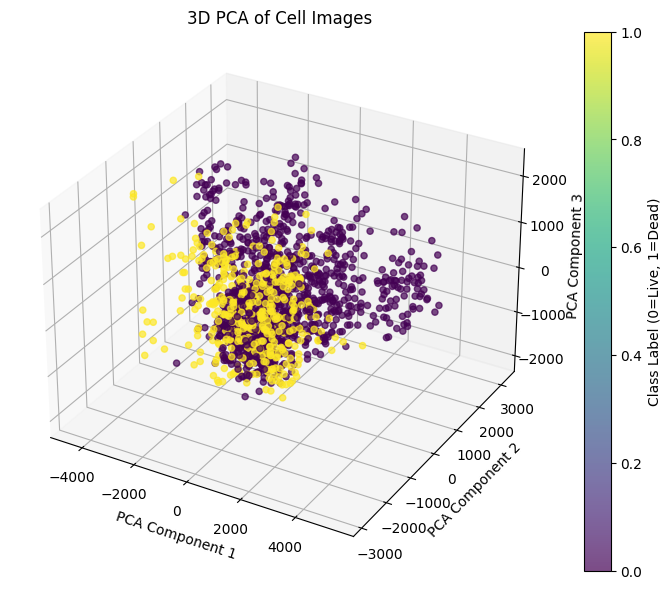

In [ ]:
# Lets take the 3D PCA of the dataset.

X_train_flat = X_train.reshape(X_train.shape[0], -1)
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_flat)

print(f"Shape of PCA transformed data: {X_train_pca.shape}")
# Lets plot the first three PCA components in 3D
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA of Cell Images')
fig.colorbar(sc, ax=ax, label='Class Label (0=Live, 1=Dead)')
plt.show()


## K-Means clustering

c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


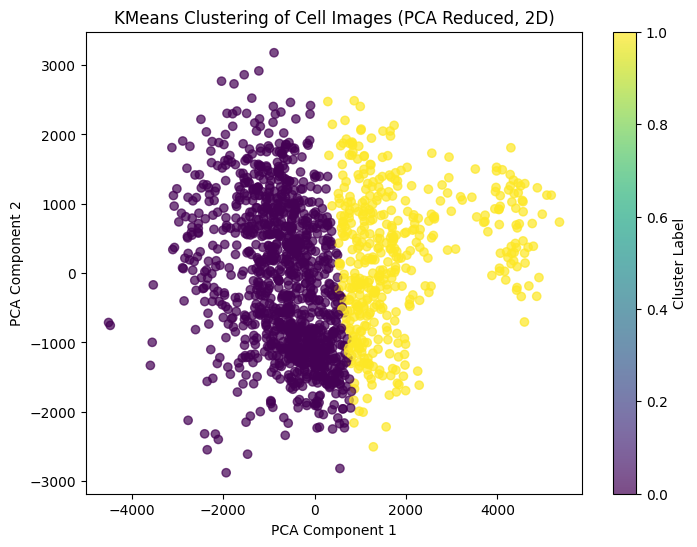

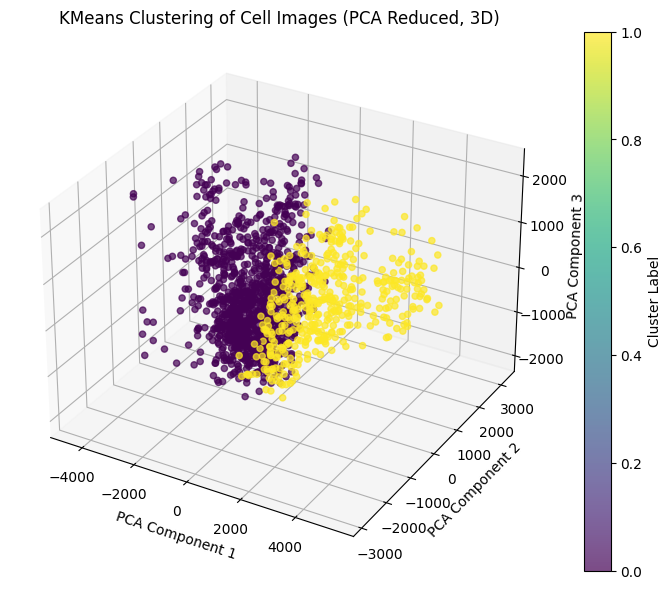

In [62]:
# Now lets cluster the data using KMeans and visualize the clusters. Since we know there will be two classes lets set k=2
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_train_pca)
y_pred = kmeans.labels_

# Plot the clustered data in 2D (PC1 vs PC2)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('KMeans Clustering of Cell Images (PCA Reduced, 2D)')
plt.colorbar(label='Cluster Label')
plt.show()

# Plot the clustered data in 3D (PC1, PC2, PC3)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 unused import
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_pred, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('KMeans Clustering of Cell Images (PCA Reduced, 3D)')
fig.colorbar(sc, ax=ax, label='Cluster Label')
plt.show()

# Evaluate clustering performance


In [63]:
# Lets use this clustering to create a model which takes the raw images, finds the frst two PCA components, and then assigns the cluster label as the predicted class.
# K-means clustering results in a decision boundary in the PCA-reduced space. We can create a simple model that first reduces the input images to their first two PCA components and then assigns the cluster label based on the K-means clustering.
def pca_kmeans_model(X):
    X_flat = X.reshape(X.shape[0], -1)
    X_pca = pca.transform(X_flat)
    cluster_labels = kmeans.predict(X_pca)
    return cluster_labels



In [64]:
# Calculate the accuracy and F1 score for the pca_kmeans_model on the training and the dev sets
from sklearn.metrics import accuracy_score, f1_score
y_train_pred = pca_kmeans_model(X_train)
y_dev_pred = pca_kmeans_model(X_dev)
train_accuracy = accuracy_score(y_train, y_train_pred)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Development Accuracy: {dev_accuracy:.4f}")
train_f1 = f1_score(y_train, y_train_pred)
dev_f1 = f1_score(y_dev, y_dev_pred)
print(f"Training F1 Score: {train_f1:.4f}")
print(f"Development F1 Score: {dev_f1:.4f}")

Training Accuracy: 0.6296
Development Accuracy: 0.6684
Training F1 Score: 0.3314
Development F1 Score: 0.3600
